# Customer Churn Prediction & Segmentation
### Telco Customer Churn Dataset
**Sections:** EDA → Data Preprocessing → Random Forest (Churn Prediction) → Customer Segmentation (KMeans)

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [3]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [4]:
df.shape

(7043, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## 2. Exploratory Data Analysis (EDA)

In [6]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


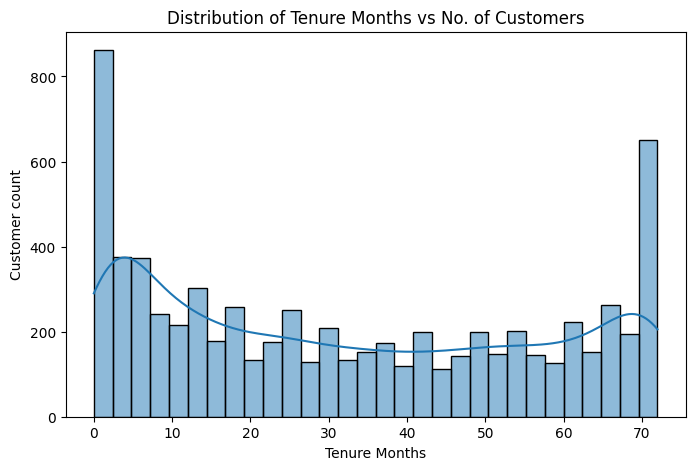

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs No. of Customers')
plt.show()

In [8]:
df['Tenure Months'].max()

72

In [9]:
df['Tenure Months'].min()

0

## 3. Data Preprocessing

In [10]:
# Drop non-predictive or leakage columns
cols_to_drop = ['CustomerID', 'Count', 'Country', 'State', 'City',
                'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
                'Churn Score', 'CLTV', 'Churn Reason', 'Churn Label']
df = df.drop(columns=cols_to_drop, errors='ignore')
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [11]:
# Convert Total Charges to numeric (it may be stored as object)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

/tmp/ipykernel_1130/1154501872.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)


In [12]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
1,0,0,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
2,0,0,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,1
3,0,0,1,1,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05,1
4,1,0,0,1,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,5036.30,1


In [13]:
# Define features and target
X = df.drop(columns=['Churn Value'])
Y = df['Churn Value']
print('Features shape:', X.shape)
print('Target shape:', Y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


## 4. Random Forest – Hyperparameter Tuning (Grid Search)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    classification_report
)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [15]:
# Grid search over n_estimators and max_depth
n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list = [5, 10, 15, 20]
results = []

for n_trees in n_estimators_list:
    for depth in max_depth_list:
        rf = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            random_state=42,
            class_weight='balanced'
        )
        rf.fit(X_train, Y_train)
        y_pred = rf.predict(X_test)
        accuracy  = accuracy_score(Y_test, y_pred)
        recall    = recall_score(Y_test, y_pred)
        precision = precision_score(Y_test, y_pred)
        f1        = f1_score(Y_test, y_pred)
        results.append({
            'Trees': n_trees,
            'Depth': depth,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1
        })

result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by=['Recall', 'Accuracy'], ascending=False)
print(result_df.head(20))

    Trees  Depth  Accuracy  Recall  Precision  F1 Score
16    500      5  0.754436  0.8125   0.545302  0.652610
12    400      5  0.754436  0.8100   0.545455  0.651911
8     300      5  0.752307  0.8075   0.542857  0.649246
0     100      5  0.754436  0.8050   0.545763  0.650505
4     200      5  0.750887  0.7975   0.541596  0.645096
9     300     10  0.789922  0.7350   0.607438  0.665158
13    400     10  0.789922  0.7350   0.607438  0.665158
5     200     10  0.788502  0.7350   0.604938  0.663657
17    500     10  0.791341  0.7325   0.610417  0.665909
1     100     10  0.788502  0.7325   0.605372  0.662896
6     200     15  0.800568  0.6025   0.663912  0.631717
2     100     15  0.801278  0.6000   0.666667  0.631579
18    500     15  0.797019  0.6000   0.655738  0.626632
10    300     15  0.797729  0.5975   0.658402  0.626474
14    400     15  0.797019  0.5950   0.657459  0.624672
15    400     20  0.794180  0.5175   0.680921  0.588068
19    500     20  0.793471  0.5175   0.678689  0

## 5. Feature Selection with Random Forest Importances

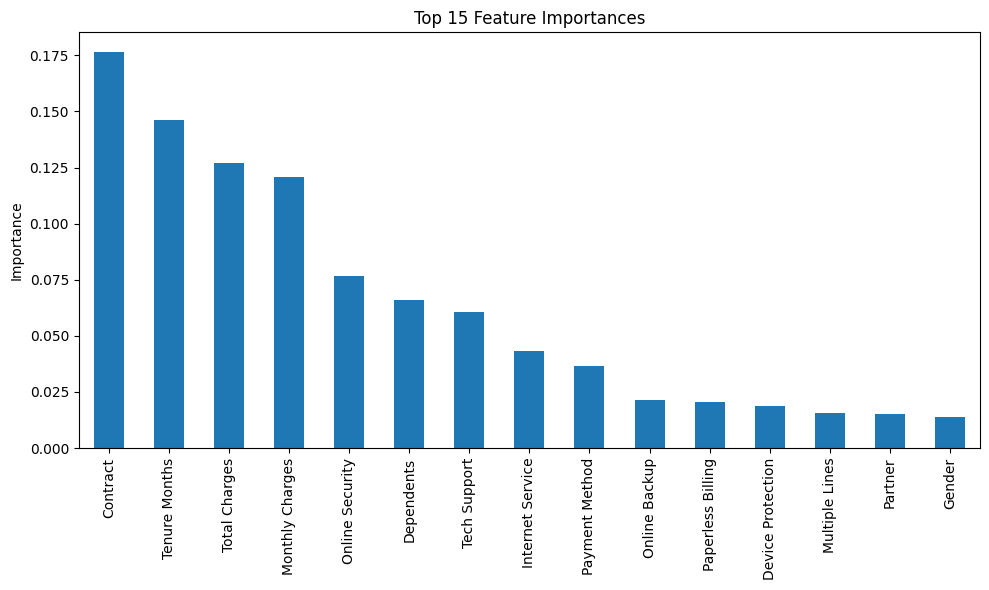

In [16]:
# Train best model (300 trees, depth 10 as per sir's code)
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_tuned.fit(X_train, Y_train)

# Feature importances
importances = pd.Series(rf_tuned.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='bar')
plt.title('Top 15 Feature Importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [17]:
# Select top features (threshold = mean importance)
threshold = importances.mean()
selected_features = importances[importances >= threshold].index.tolist()
print('Selected features:', selected_features)
X_selected = X[selected_features]

Selected features: ['Contract', 'Tenure Months', 'Total Charges', 'Monthly Charges', 'Online Security', 'Dependents', 'Tech Support']


In [18]:
# Train/test split on selected features
X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(
    X_selected, Y, test_size=0.2, random_state=42
)

In [19]:
# Final model on selected features
rf_selected = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_selected.fit(X_train_sel, Y_train_sel)
y_pred_selected = rf_selected.predict(X_test_sel)

print(classification_report(Y_test_sel, y_pred_selected))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1009
           1       0.58      0.73      0.65       400

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.78      1409



## 6. Churn Probability Prediction

In [20]:
# Predict churn probability on the full dataset
y_prob = rf_tuned.predict_proba(X)
churn_probability = y_prob[:, 1]
print('Shape:', churn_probability.shape)
print('First 5 probabilities:', churn_probability[:5])

Shape: (7043,)
First 5 probabilities: [0.75654844 0.81122223 0.82616391 0.59801547 0.6464908 ]


## 7. Customer Segmentation with KMeans

In [21]:
# Build segmentation dataframe
# Load original df again to get original numeric columns
df_orig = pd.read_excel("Telco_customer_churn.xlsx")
df_orig['Total Charges'] = pd.to_numeric(df_orig['Total Charges'], errors='coerce')
df_orig['Total Charges'].fillna(df_orig['Total Charges'].median(), inplace=True)

segmentation_data = pd.DataFrame({
    'Tenure Months':   df_orig['Tenure Months'],
    'Monthly Charges': df_orig['Monthly Charges'],
    'Total Charges':   df_orig['Total Charges'],
    'Churn Probability': churn_probability
})
segmentation_data.head()

/tmp/ipykernel_1130/2157832658.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_orig['Total Charges'].fillna(df_orig['Total Charges'].median(), inplace=True)


,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.756548
1,2,70.70,151.65,0.811222
2,8,99.65,820.50,0.826164
3,28,104.80,3046.05,0.598015
4,49,103.70,5036.30,0.646491


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.95967407  1.30220741]
 [-1.23672422  0.19736523 -0.9404697   1.4780987 ]
 [-0.99240204  1.1595457  -0.64518597  1.52616763]
 [-0.17799476  1.33071079  0.33734927  0.79219029]
 [ 0.67713287  1.29415125  1.21600434  0.94814048]]


In [ ]:
dummy_placeholder

In [99]:
dummy_placeholder_for_truncated_content

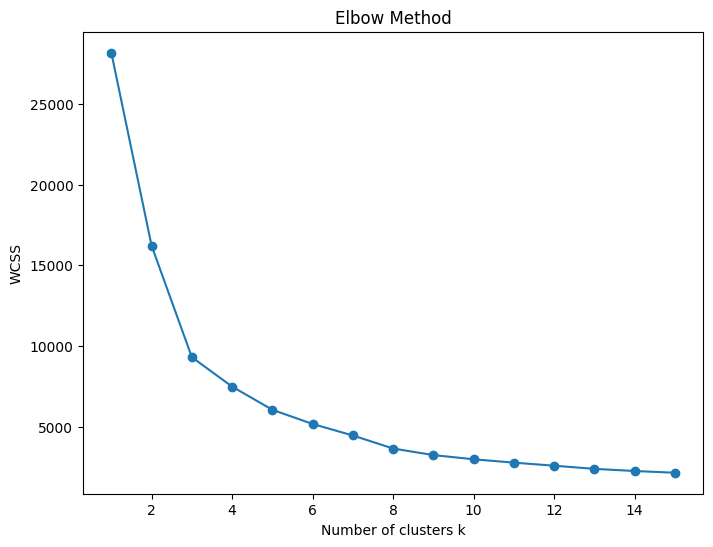

In [23]:
from sklearn.cluster import KMeans

# Elbow method to find optimal k
wcss = []
for k in range(1, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 16), wcss, marker='o')
plt.xlabel('Number of clusters k')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [24]:
# Fit KMeans with k=3 (sir's choice)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
segmentation_data['Cluster'] = clusters
segmentation_data.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.756548,1
1,2,70.70,151.65,0.811222,1
2,8,99.65,820.50,0.826164,1
3,28,104.80,3046.05,0.598015,1
4,49,103.70,5036.30,0.646491,2


In [25]:
cluster_summary = segmentation_data.groupby('Cluster').mean()
print(cluster_summary)

         Tenure Months  Monthly Charges  Total Charges  Churn Probability
Cluster                                                                  
0            31.200083        33.488394    1039.360659           0.118241
1            11.175859        72.862830     908.186731           0.695093
2            58.503978        90.457511    5288.083622           0.212522


In [26]:
cluster_names = {
    0: 'Budget Loyal Customers',
    1: 'High Risk New Customers',
    2: 'Loyal Premium Customers'
}
segmentation_data['Cluster Segment'] = segmentation_data['Cluster'].map(cluster_names)
segmentation_data.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.756548,1,High Risk New Customers
1,2,70.70,151.65,0.811222,1,High Risk New Customers
2,8,99.65,820.50,0.826164,1,High Risk New Customers
3,28,104.80,3046.05,0.598015,1,High Risk New Customers
4,49,103.70,5036.30,0.646491,2,Loyal Premium Customers


## 8. Visualisations – Cluster Segments

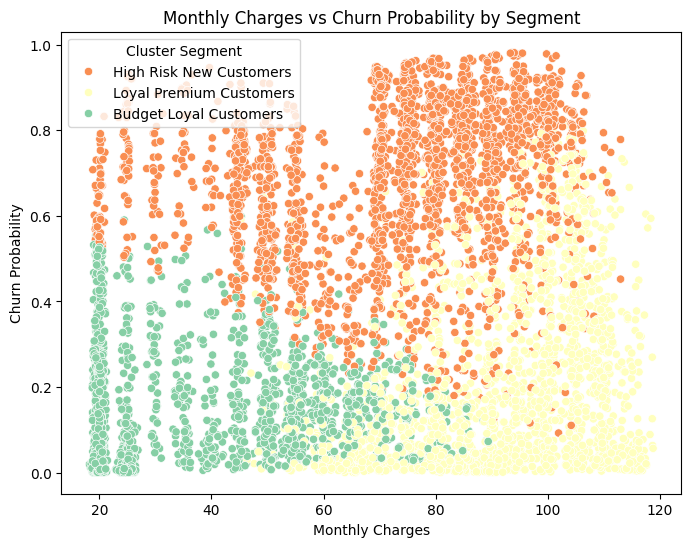

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Monthly Charges', y='Churn Probability',
    hue='Cluster Segment', data=segmentation_data,
    palette='Spectral'
)
plt.title('Monthly Charges vs Churn Probability by Segment')
plt.show()

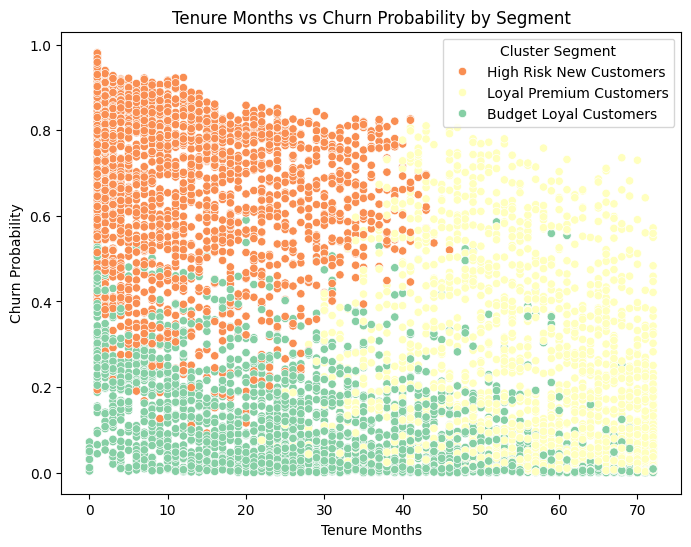

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Tenure Months', y='Churn Probability',
    hue='Cluster Segment', data=segmentation_data,
    palette='Spectral'
)
plt.title('Tenure Months vs Churn Probability by Segment')
plt.show()

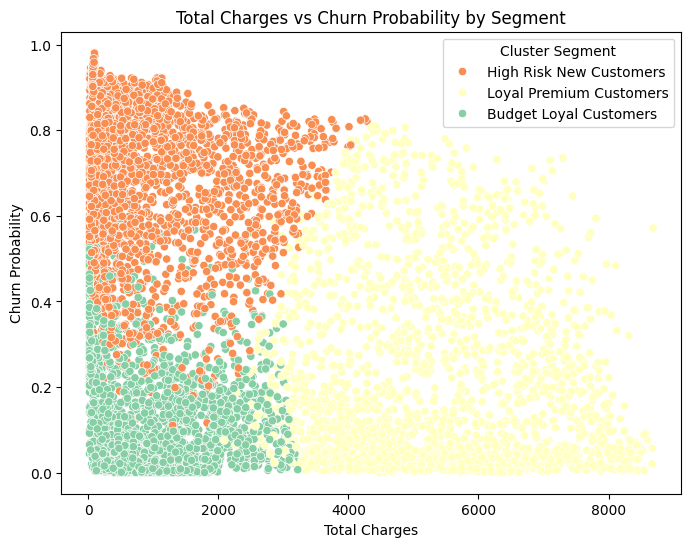

In [29]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Total Charges', y='Churn Probability',
    hue='Cluster Segment', data=segmentation_data,
    palette='Spectral'
)
plt.title('Total Charges vs Churn Probability by Segment')
plt.show()